# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 22 - 5to bimestre 2025


Este tercer y último TP se debe entregar hasta las **23hs del viernes 12 de diciembre (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/kscHDArwzdvrTSG99)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co22.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [2]:
import gdown
import zipfile
import os

url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL   = '/content/datos_zip/dataset_emociones/validation'


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=808582f2-04c4-46f9-a3dd-aecd76d6f807
To: /home/jiteich/repos/ceia/deeplearning/TP3/archivo.zip
100%|██████████| 40.0M/40.0M [00:06<00:00, 5.86MB/s]


## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



In [3]:
import matplotlib.pyplot as plt
import torchvision
import torch
from torchvision import transforms
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
mean = 0
std = 1

composition = transforms.Compose([
    transforms.Resize(size=100),
    transforms.CenterCrop(size=100),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [5]:
batch_size = 64
dataloader = {
    'train' : torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(root='datos_zip/dataset_emociones/train/', transform=composition), batch_size=batch_size, shuffle=True, pin_memory=True),
    'test' : torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(root='datos_zip/dataset_emociones/validation/', transform=composition), batch_size=3068, shuffle=True, pin_memory=True)
    # 'test' : torchvision.datasets.ImageFolder(root='datos_zip/dataset_emociones/validation/', transform=composition)
}

In [4]:
next(iter(dataloader['test']))

[tensor([[[[0.1882, 0.2078, 0.2392,  ..., 0.1255, 0.1412, 0.1843],
           [0.2196, 0.2392, 0.2627,  ..., 0.1333, 0.1373, 0.1686],
           [0.2471, 0.2706, 0.3020,  ..., 0.1490, 0.1373, 0.1529],
           ...,
           [0.1216, 0.1137, 0.0980,  ..., 0.0784, 0.0941, 0.1333],
           [0.1373, 0.1216, 0.0941,  ..., 0.0784, 0.0863, 0.1216],
           [0.1216, 0.1059, 0.0784,  ..., 0.0941, 0.0941, 0.1216]],
 
          [[0.1647, 0.1843, 0.2039,  ..., 0.1333, 0.1490, 0.1922],
           [0.1882, 0.2078, 0.2275,  ..., 0.1412, 0.1451, 0.1765],
           [0.2078, 0.2314, 0.2549,  ..., 0.1451, 0.1333, 0.1490],
           ...,
           [0.1765, 0.1686, 0.1608,  ..., 0.1412, 0.1608, 0.2000],
           [0.1922, 0.1765, 0.1569,  ..., 0.1412, 0.1529, 0.1882],
           [0.1765, 0.1608, 0.1412,  ..., 0.1569, 0.1608, 0.1882]],
 
          [[0.1098, 0.1294, 0.1451,  ..., 0.0510, 0.0667, 0.1098],
           [0.1373, 0.1569, 0.1686,  ..., 0.0588, 0.0627, 0.0941],
           [0.1608, 0.18

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional desde cero, sin usar modelos pre-entrenados.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

Definimos el bloque base de nuestra red convolucional `conv_block`, el cual consiste de:
- 1 capa convolucional `Conv2d`.
- 1 capa de activación `LeakyReLU`.
- 1 capa de pooling `MaxPool2d`.

Se realizaron pruebas con función de activación `Tanh`, pero se obtuvieron mejores resultados con `LeakyReLU`.

In [6]:
def conv_block(i, c_in, c_out, k=3, p='same', s=1, pk=2):        
    return [                               # el módulo Sequential se engarga de hacer el forward de todo lo que tiene dentro.
        (f'conv_{i}', torch.nn.Conv2d(c_in, c_out, k, padding=k//2, stride=s)), # conv
        # (f'act_{i}', torch.nn.Tanh()),                                      # activation
        (f'act_{i}', torch.nn.LeakyReLU()),                                      # activation
        (f'pool_{i}', torch.nn.MaxPool2d(pk))                             # pooling
    ]

Ahora definimos la red en si misma, de forma que sea escalable sencillamente a mayores y más densas capas según necesite el usuario. Se ponen las siguientes capas después de los bloques convolucionales:
- 1 capa de `Flatten`.
- 1 capa de `Dropout`.
- 1 capa `Linear`.

Además a la salida de cada bloque convolucional se pone una capa de `Dropout` (a excepción de la última capa).

In [ ]:
from collections import OrderedDict
class Flatten(torch.nn.Module):
    def forward(self, X):
        return X.flatten(start_dim=1)

class CNN(torch.nn.Module):
    def __init__(self, device, img_size, layers=2, in_channels=3, n_outputs=7, ch_per_layer=4, kernel_size=2, pool_kernel_size=2):
        super().__init__()

        # Define the architecture of the CNN
        self.layers = []
        in_feats = img_size # keep track of the input size of the fully connected layer
        for i in range(layers):
            # Convolutional Layer
            self.layers += conv_block(
                i = i,
                c_in = in_channels if i==0 else ch_per_layer,
                c_out=ch_per_layer if i==0 else ch_per_layer * 2, 
                k=kernel_size, 
                pk=pool_kernel_size,
                p=1
                )
            # Dropout Layer
            if i != layers - 1:
                self.layers.append((f'drop_{i}', torch.nn.Dropout2d(p=0.1, inplace=False)))

            # x2 channel amount
            if i > 0:
                ch_per_layer *= 2

            in_feats = 1 + int((in_feats + 2*0 - 1 * (pool_kernel_size-1))/pool_kernel_size)
        # Fully conected Layer
        in_feats = in_feats**2 * ch_per_layer
        self.layers.append(('flatten', Flatten()))
        self.layers.append(('drop', torch.nn.Dropout(p=0.1)))
        self.layers.append(('fully_connected', torch.nn.Linear(
            # in_features=(img_size * img_size / (pool_kernel_size * layers)), 
            in_features=in_feats, 
            out_features=n_outputs
            )))
        self.network = torch.nn.Sequential(
            OrderedDict(self.layers)
        ).to(device)

        print('----------------------------------------------')
        print('Red creada:')
        print(self.network)
        print('----------------------------------------------')
    
    def forward(self, X):
        y = self.network(X)
        return y

Probemos armar una red con hiperparámetros cualquiera:

In [ ]:
model = CNN(device=device, img_size=100, in_channels=3, layers=3, ch_per_layer=4, kernel_size=4, pool_kernel_size=2)

----------------------------------------------
Red creada:
Sequential(
  (conv_0): Conv2d(3, 4, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_0): LeakyReLU(negative_slope=0.01)
  (pool_0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_0): Dropout2d(p=0.1, inplace=False)
  (conv_1): Conv2d(4, 8, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_1): LeakyReLU(negative_slope=0.01)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_1): Dropout2d(p=0.1, inplace=False)
  (conv_2): Conv2d(8, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_2): LeakyReLU(negative_slope=0.01)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten()
  (drop): Dropout(p=0.5, inplace=False)
  (fully_connected): Linear(in_features=2704, out_features=7, bias=True)
)
----------------------------------------------


In [ ]:
import torchinfo as torchinfo

torchinfo.summary(model, input_size=[1,3,100,100])

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 7]                    --
├─Sequential: 1-1                        [1, 7]                    --
│    └─Conv2d: 2-1                       [1, 4, 101, 101]          196
│    └─LeakyReLU: 2-2                    [1, 4, 101, 101]          --
│    └─MaxPool2d: 2-3                    [1, 4, 50, 50]            --
│    └─Dropout2d: 2-4                    [1, 4, 50, 50]            --
│    └─Conv2d: 2-5                       [1, 8, 51, 51]            520
│    └─LeakyReLU: 2-6                    [1, 8, 51, 51]            --
│    └─MaxPool2d: 2-7                    [1, 8, 25, 25]            --
│    └─Dropout2d: 2-8                    [1, 8, 25, 25]            --
│    └─Conv2d: 2-9                       [1, 16, 26, 26]           2,064
│    └─LeakyReLU: 2-10                   [1, 16, 26, 26]           --
│    └─MaxPool2d: 2-11                   [1, 16, 13, 13]           --
│    └─Fla

Definimos ahora funciones para entrenar y testear el modelo:

In [10]:
def train_model(model, train_dataloader, test_dataloader, epochs, optimizer, loss):
    loss_evol = []
    ac_evol = []
    recall_evol = []
    f1_evol = []
    loss_test_evol = []
    ac_test_evol = []
    recall_test_evol = []
    f1_test_evol = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = []
        epoch_recall = []
        epoch_f1 = []
        corrects = 0
        samples = 0
        for x_i, y_i in train_dataloader:
            x_i, y_i = x_i.to(device), y_i.to(device)
            yhat = model(x_i)
            loss_i = loss(yhat, y_i)
            optimizer.zero_grad(set_to_none=True)
            loss_i.backward()
            optimizer.step()

            epoch_loss.append(loss_i.item())

            preds_classes = yhat.argmax(dim=1)
            epoch_recall.append(recall_score(y_i.cpu(), preds_classes.cpu(), average='weighted', zero_division=np.nan))
            epoch_f1.append(f1_score(y_i.cpu(), preds_classes.cpu(), average='weighted'))
            corrects += (preds_classes == y_i).sum().item()
            samples += y_i.size(0)

        loss_evol.append(np.mean(epoch_loss))
        ac_evol.append(corrects/samples)
        recall_evol.append(np.mean(epoch_recall))
        f1_evol.append(np.mean(epoch_f1))

        test_loss, test_ac, test_recall, test_f1 = test_model(model, test_dataloader, loss)
        loss_test_evol.append(test_loss)
        ac_test_evol.append(test_ac)
        recall_test_evol.append(test_recall)
        f1_test_evol.append(test_f1)

        print(f'Epoch {epoch}:')
        print(f' Train Loss = {np.mean(epoch_loss):.4f}')
        print(f' Train Accuracy = {100 * corrects/samples:.0f}%')
        print(f' Test Loss = {test_loss:.4f}')
        print(f' Test Accuracy = {100 * test_ac:.0f}%')
        print(f'')

    return loss_evol, ac_evol, recall_evol, f1_evol, loss_test_evol, ac_test_evol, recall_test_evol, f1_test_evol

def test_model(model, test_dataloader, loss):
    model.eval()
    X_test, y_test = next(iter(test_dataloader))
    X_test, y_test = X_test.to(device), y_test.to(device)
    with torch.no_grad():
        yhat_test = model(X_test)

        preds_classes_test = yhat_test.argmax(dim=1)
        corrects_test = (preds_classes_test == y_test).sum().item()
        samples_test = y_test.size(0)
        ac_test = corrects_test / samples_test
        # print(f'Accuracy in test = {100*ac_test:.2f}%')

        loss_test = loss(yhat_test, y_test).item()
        # print(f'Loss in test = {loss_test:.4f}%')

        recall_test = recall_score(y_test.cpu(), preds_classes_test.cpu(), average='weighted', zero_division=np.nan)
        f1_test = f1_score(y_test.cpu(), preds_classes_test.cpu(), average='weighted')

    return loss_test, ac_test, recall_test, f1_test 


Ahora sí podemos entrenar un modelo de la siguiente forma:

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = torch.nn.CrossEntropyLoss()

epochs = 30
loss_evol, ac_evol, loss_evol_test, ac_evol_test = train_model(model, dataloader['train'], dataloader['train'], epochs, optimizer, loss)


/home/jiteich/repos/ceia/deeplearning/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (30,) and (0,)

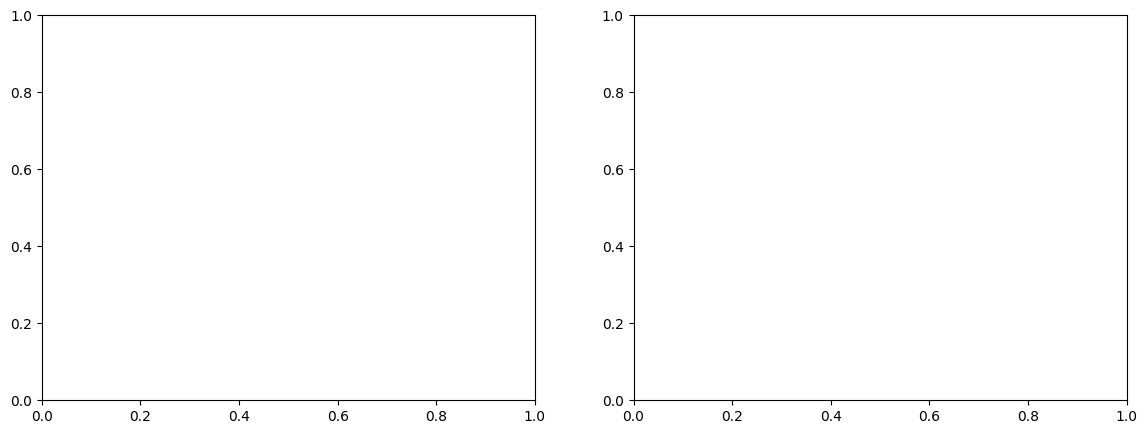

In [16]:
fig, axs = plt.subplots(1,2, figsize=(14,5))
axs[0].plot(range(epochs), ac_evol, label='train')
axs[0].plot(range(epochs), ac_evol_test, label='test')
axs[0].set_title('Evolución de la precisión')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epochs')
axs[0].set_xlim(0, epochs-1)
axs[0].legend()

axs[1].plot(range(epochs), loss_evol, label='train')
axs[1].plot(range(epochs), loss_evol_test, label='test')
axs[1].set_title('Evolución de la pérdida')
axs[1].set_ylabel('Loss (Cross Entropy)')
axs[1].set_xlabel('Epochs')
axs[1].set_xlim(0, epochs-1)

In [16]:
model.eval()
X_test, y_test = next(iter(dataloader['test']))
X_test, y_test = X_test.to(device), y_test.to(device)
with torch.no_grad():
    yhat_test = model(X_test)

preds_classes_test = yhat_test.argmax(dim=1)
corrects_test = (preds_classes_test == y_test).sum().item()
samples_test = y_test.size(0)
ac_test = corrects_test / samples_test
print(f'Accuracy in test = {100*ac_test:.2f}%')

Accuracy in test = 73.44%


Realicemos un grid search para encontrar los valores óptimos de hiperparámetros.

In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(torchvision.datasets.ImageFolder(root='datos_zip/dataset_emociones/train/', transform=composition), test_size=0.5)
dataloader_train = torch.utils.data.DataLoader(data_train, batch_size=128, shuffle=True)
# X_val, y_val = torch.tensor([data_val[i][0] for i in range(len(data_val))]) , torch.tensor([data_val[i][1] for i in range(len(data_val))])
X_val, y_val = [data_val[i][0] for i in range(len(data_val))] , [data_val[i][1] for i in range(len(data_val))]
X_val, y_val = torch.stack(X_val), torch.tensor(y_val)
X_val, y_val = X_val.to(device), y_val.to(device)
dataloader_val = torch.utils.data.DataLoader(data_val, batch_size=128, shuffle=True)
# hyperparameter grid search
models = []
for layers in [3,4,5]:
    for ch_per_layer in [4,8,12]:
        for kernel in [4,8,12]:
            model = CNN(device=device, img_size=100, in_channels=3, layers=layers, ch_per_layer=ch_per_layer, kernel_size=kernel, pool_kernel_size=2)
            print('Model with:')
            print(f'    layers={layers}')
            print(f'    ch_per_layer={ch_per_layer}')
            print(f'    kernel={kernel}')
            models.append({
                'layers' : layers,
                'ch_per_layer' : ch_per_layer,
                'kernel' : kernel
            })
            # torchinfo.summary(model, input_size=[1,3,100,100])

            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
            loss = torch.nn.CrossEntropyLoss()

            ac_evol = []
            loss_evol = []
            epochs = 40

            for epoch in range(epochs):
                model.train()
                epoch_loss = []
                corrects = 0
                samples = 0
                # for x_i, y_i in dataloader['train']:
                for x_i, y_i in dataloader_train:
                    x_i, y_i = x_i.to(device), y_i.to(device)
                    yhat = model(x_i)
                    # yhat = yhat.squeeze(dim=1)
                    # yhat = torch.tensor(yhat.argmax(dim=1))
                    loss_i = loss(yhat, y_i)
                    optimizer.zero_grad(set_to_none=True)
                    loss_i.backward()
                    optimizer.step()
                    epoch_loss.append(loss_i.item())

                    preds_classes = yhat.argmax(dim=1)
                    corrects += (preds_classes == y_i).sum().item()
                    samples += y_i.size(0)
                    # print(f'ac={corrects/samples:.4f}')
                epoch_loss = np.mean(epoch_loss)
                loss_evol.append(epoch_loss)
                ac_evol.append(corrects/samples)
                # print(f'Epoch {epoch} Loss = {epoch_loss}')
                # print(f'Epoch {epoch} Accuracy = {100 * corrects/samples:.0f}%')
            print(f'Training loss = {epoch_loss}')
            print(f'Training accuracy = {ac_evol[-1]*100:.2f}%')
            models[-1]['train-loss'] = epoch_loss
            models[-1]['train-accuracy'] = ac_evol[-1]*100
            

            model.eval()
            # X_test, y_test = next(iter(dataloader['test']))
            with torch.no_grad():
                yhat_test = model(X_val)

            preds_classes_test = yhat_test.argmax(dim=1)
            corrects_test = (preds_classes_test == y_val).sum().item()
            samples_test = y_val.size(0)
            ac_test = corrects_test / samples_test
            print(f'Accuracy in test = {100*ac_test:.2f}%')
            models[-1]['test-accuracy'] = ac_test*100

hypr_gridsearch = pd.DataFrame(models)
hypr_gridsearch

----------------------------------------------
Red creada:
Sequential(
  (conv_0): Conv2d(3, 4, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_0): LeakyReLU(negative_slope=0.01)
  (pool_0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_0): Dropout2d(p=0.1, inplace=False)
  (conv_1): Conv2d(4, 8, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_1): LeakyReLU(negative_slope=0.01)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_1): Dropout2d(p=0.1, inplace=False)
  (conv_2): Conv2d(8, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_2): LeakyReLU(negative_slope=0.01)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten()
  (drop): Dropout(p=0.5, inplace=False)
  (fully_connected): Linear(in_features=2704, out_features=7, bias=True)
)
----------------------------------------------
Model with:
    layers=3
    ch_per_laye

,layers,ch_per_layer,kernel,train-loss,train-accuracy,test-accuracy
0,3,4,4,0.726636,74.229829,69.866362
1,3,4,8,0.616523,77.457213,70.306389
2,3,4,12,0.600600,77.718011,68.921121
3,3,8,4,0.474644,82.624287,72.555411
4,3,8,8,0.334849,87.986960,72.490222
5,3,8,12,0.408918,85.183374,69.442634
6,3,12,4,0.295163,88.883456,73.305085
7,3,12,8,0.188831,93.121434,73.728814
8,3,12,12,0.301739,89.079055,70.844198
9,4,4,4,0.806937,71.149144,69.556714


In [69]:
hypr_gridsearch['train-test-rel'] = hypr_gridsearch['train-accuracy'] / hypr_gridsearch['test-accuracy']

A continuación vemos la relación entre precisión con el dataset de train y precisión con el dataset de validación. Lo ideal es tener un modelo que generalice a igual precisión que cuando entrena. Si el modelo presenta una precisión muy superior en entrenamiento frente a validación, esto nos indica que estamos teniendo sobre ajuste.

Podemos observar que:
- Al aumentar la cantidad de capas nos alejamos de la línea ideal, con 2 puntos buenos con 3 y 4 capas.
- Al aumentar la cantidad de canales por capa se tiene un efecto aún más marcado en la distancia al modelo ideal.
- Al aumentar el tamaño del kernel no se tiene tanta diferencia en algunos casos, pero si se aprecia que los mejores generalizadores tienen valor 4 de kernel

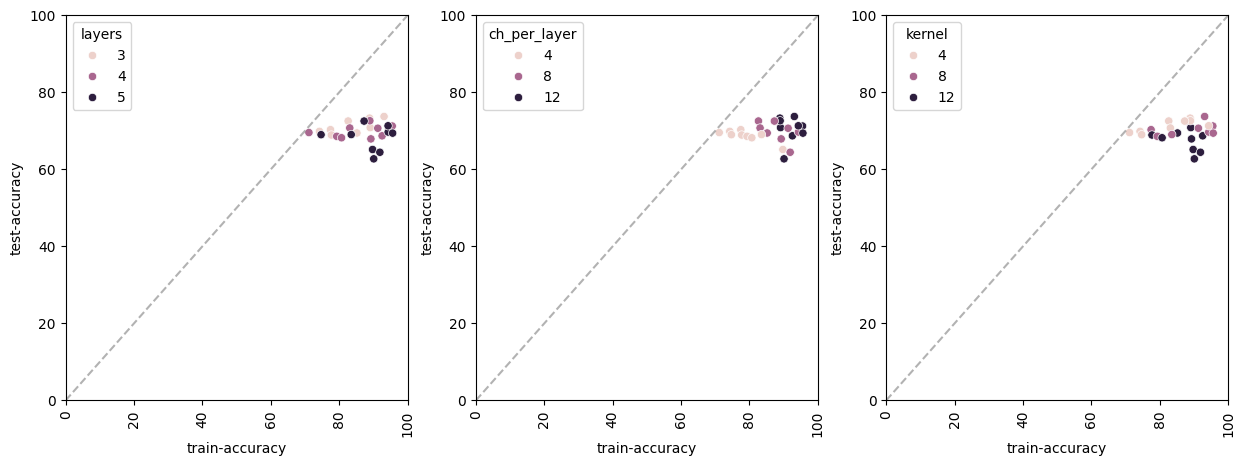

In [71]:
import seaborn as sns
fig, axs = plt.subplots(1,3,figsize=(15,5))
sns.scatterplot(data=hypr_gridsearch, x='train-accuracy' ,y='test-accuracy', hue='layers', ax=axs[0])
sns.scatterplot(data=hypr_gridsearch, x='train-accuracy' ,y='test-accuracy', hue='ch_per_layer', ax=axs[1])
sns.scatterplot(data=hypr_gridsearch, x='train-accuracy' ,y='test-accuracy', hue='kernel', ax=axs[2])
for i in range(3):
    axs[i].tick_params(axis='x', rotation=90)
    axs[i].set_ylim(0,100)
    axs[i].set_xlim(0,100)
    axs[i].plot([0,100],[0,100], linestyle='dashed', color='grey', alpha=0.6)
# plt.legend()

# plt.bar(hypr_gridsearch['train-accuracy'], y=)

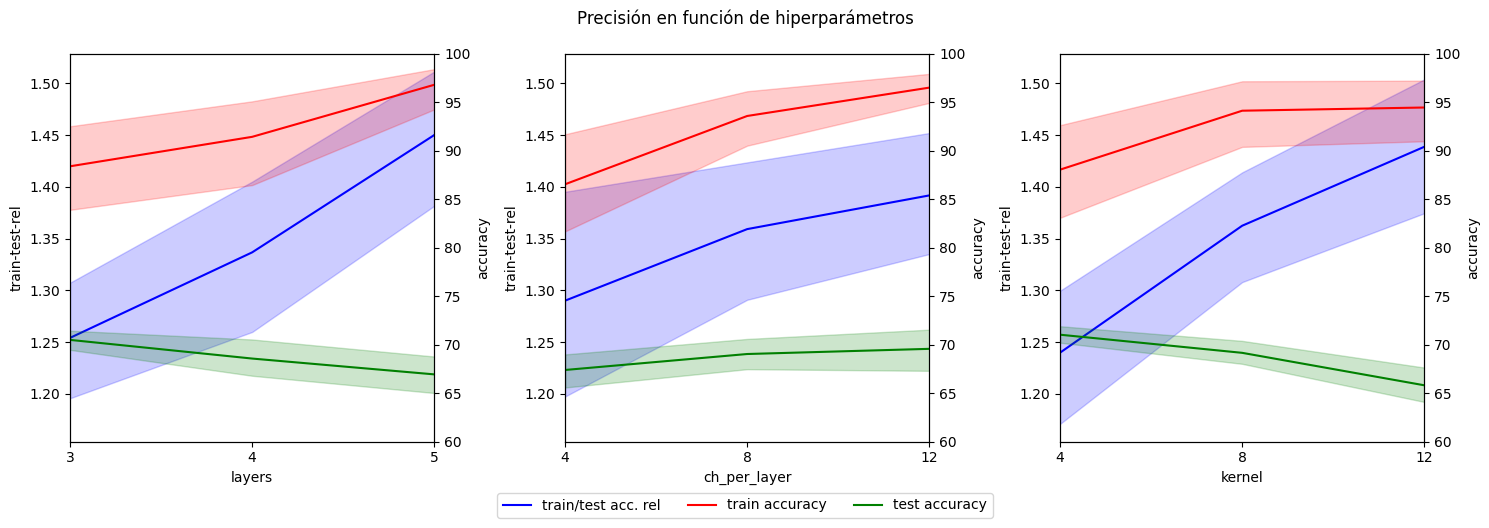

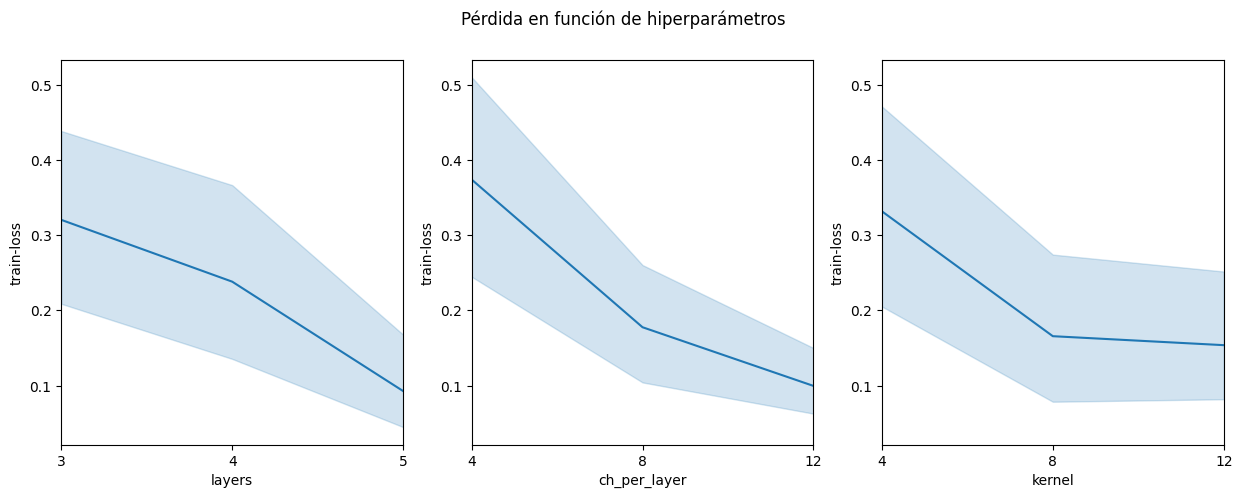

In [94]:
fig, axs = plt.subplots(1,3,figsize=(15,5),sharey=True)
# para mostrar los yticks en todos los gráficos
axs[1].yaxis.set_tick_params(labelbottom=True)
axs[2].yaxis.set_tick_params(labelbottom=True)

def hypr_comparison_plot(ax, hypr, data):
    ax.set_xlim(data[hypr].min(), data[hypr].max())
    ax.set_xticks(data[hypr].unique())
    sns.lineplot(data=data, x=hypr, y='train-test-rel',ax=ax, color='blue', label='train/test acc. rel')
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()
    ax_01 = ax.twinx()
    ax_01.set_ylabel('accuracy')
    ax_01.set_ylim(60,100)
    sns.lineplot(data=hypr_gridsearch, x=hypr, y='train-accuracy',ax=ax_01, color='red', label='train accuracy')
    sns.lineplot(data=hypr_gridsearch, x=hypr, y='test-accuracy',ax=ax_01, color='green', label='test accuracy')
    handles2, labels2 = ax_01.get_legend_handles_labels()
    ax_01.get_legend().remove()
    # ax.legend(handles=handles+handles2)
    return handles+handles2

handles = hypr_comparison_plot(ax=axs[0], hypr='layers', data=hypr_gridsearch)
_ = hypr_comparison_plot(ax=axs[1], hypr='ch_per_layer', data=hypr_gridsearch)
_ = hypr_comparison_plot(ax=axs[2], hypr='kernel', data=hypr_gridsearch)
fig.legend(
    handles=handles,
    bbox_to_anchor=(0.5, -0.05), 
    loc='lower center',
    ncol=3
)
fig.suptitle('Precisión en función de hiperparámetros')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,3,figsize=(15,5),sharey=True)
# para mostrar los yticks en todos los gráficos
axs[1].yaxis.set_tick_params(labelbottom=True)
axs[2].yaxis.set_tick_params(labelbottom=True)
for idx, hypr in enumerate(['layers', 'ch_per_layer', 'kernel']):
    sns.lineplot(data=hypr_gridsearch, x=hypr, y='train-loss',ax=axs[idx])
    axs[idx].set_xlim(hypr_gridsearch[hypr].min(), hypr_gridsearch[hypr].max())
    axs[idx].set_xticks(hypr_gridsearch[hypr].unique())
# sns.lineplot(data=hypr_gridsearch, x='ch_per_layer', y='train-loss',ax=axs[1])
# sns.lineplot(data=hypr_gridsearch, x='kernel', y='train-loss',ax=axs[2])
fig.suptitle('Pérdida en función de hiperparámetros')
plt.show()

Se tienen 2 tipos de gráficos en función de los hiperparámetros:
- Gráfico de precisión: se grafica la precisión en entrenamiento y en validación, así como también la relación entre ambos. Lo que se busca con esto último es intentar evitar tener sobreajuste, lo cual se evidencia al tener una precisión de entrenamiento muy superior a la de validación.
- Gráfico de pérdida de entrenamiento.

Analicemos los resultados:
- En cuanto al analísis de precisión en función de los hiperparámetros, se obtiene una relación casi igual en todos los casos, donde al tener un modelo más denso se empieza a tener sobreajuste, especialmente al aumentar la cantidad de capas y la dimensión del kernel. Con los canales por capa, se tiene un aumento de sobreajuste, aunque si se mejora (levemente) la precisión del set de validación, algo que con los otros 2 hiperparámetros empeora.
- En cuanto a la pérdida, observamos que al aumentar todos los hiperparámetros se disminuye la pérdida en el entrenamiento, pero nuevamente el hiperparámetro que más influencia tiene son los canales por capa, donde se parte del mayor valor y se termina en el menor valor de pérdida.

Se concluye utilizar la siguiente arquitectura:
- `layers` = 3
- `ch_per_layers` = 8
- `kernel` = 4

In [21]:
model = CNN(device=device, img_size=100, in_channels=3, layers=3, ch_per_layer=8, kernel_size=4, pool_kernel_size=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = torch.nn.CrossEntropyLoss()
epochs = 100

loss_evol, ac_evol, loss_evol_test, ac_evol_test = train_model(model, dataloader['train'], dataloader['test'], epochs, optimizer, loss)

----------------------------------------------
Red creada:
Sequential(
  (conv_0): Conv2d(3, 8, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_0): LeakyReLU(negative_slope=0.01)
  (pool_0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_0): Dropout2d(p=0.1, inplace=False)
  (conv_1): Conv2d(8, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_1): LeakyReLU(negative_slope=0.01)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_1): Dropout2d(p=0.1, inplace=False)
  (conv_2): Conv2d(16, 32, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_2): LeakyReLU(negative_slope=0.01)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten()
  (drop): Dropout(p=0.5, inplace=False)
  (fully_connected): Linear(in_features=5408, out_features=7, bias=True)
)
----------------------------------------------
Epoch 0:
 Train Loss = 1.5778
 Train A

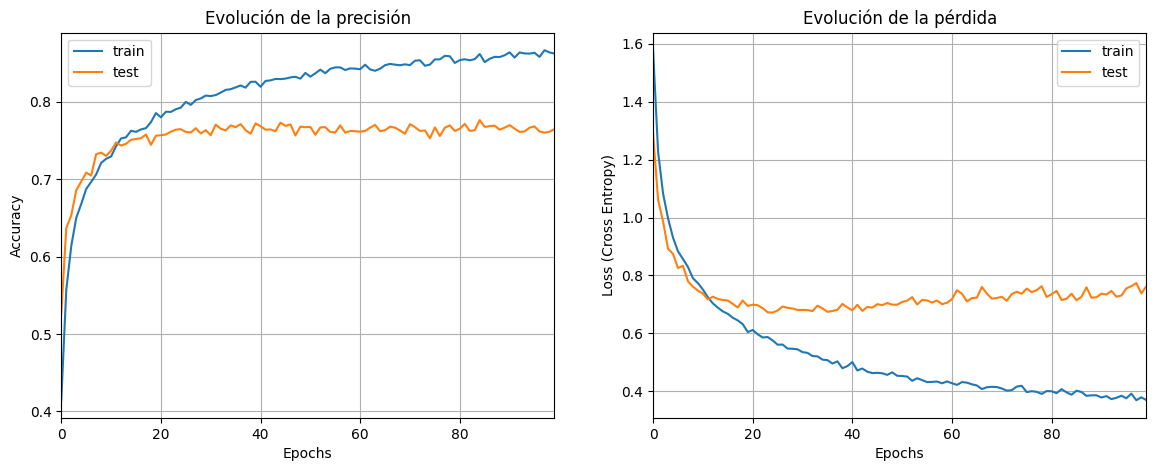

In [23]:
fig, axs = plt.subplots(1,2, figsize=(14,5))
axs[0].plot(range(epochs), ac_evol, label='train')
axs[0].plot(range(epochs), ac_evol_test, label='test')
axs[0].set_title('Evolución de la precisión')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epochs')
axs[0].set_xlim(0, epochs-1)
axs[0].grid()
axs[0].legend()

axs[1].plot(range(epochs), loss_evol, label='train')
axs[1].plot(range(epochs), loss_evol_test, label='test')
axs[1].set_title('Evolución de la pérdida')
axs[1].set_ylabel('Loss (Cross Entropy)')
axs[1].set_xlabel('Epochs')
axs[1].set_xlim(0, epochs-1)
axs[1].grid()
axs[1].legend()

**Análisis del learning rate y epochs de entrenamiento**

A continuación se analzian 3 posibles learning rates: 1e-3, 1e-4, 5e-5. Los 3 casos se corren 200 epochs de entrenamiento. Se busca encontrar el learning rate óptimo y las epochs de entrenamiento óptimas.

In [62]:
lr_comp = {}
for lr in [1e-3, 1e-4, 5e-5]:
    model = CNN(device=device, img_size=100, in_channels=3, layers=3, ch_per_layer=8, kernel_size=4, pool_kernel_size=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss = torch.nn.CrossEntropyLoss()
    epochs = 200

    loss_evol, ac_evol, recall_evol, f1_evol, loss_evol_test, ac_evol_test, recall_evol_test, f1_evol_test = train_model(model, dataloader['train'], dataloader['test'], epochs, optimizer, loss)

    lr_comp[lr] = {}
    lr_comp[lr]['model'] = model
    lr_comp[lr]['loss_evol'] = loss_evol
    lr_comp[lr]['ac'] = ac_evol
    lr_comp[lr]['recall'] = recall_evol
    lr_comp[lr]['f1'] = f1_evol
    lr_comp[lr]['loss_evol_test'] = loss_evol_test
    lr_comp[lr]['ac_test'] = ac_evol_test
    lr_comp[lr]['recall_test'] = recall_evol_test
    lr_comp[lr]['f1_test'] = f1_evol_test

----------------------------------------------
Red creada:
Sequential(
  (conv_0): Conv2d(3, 8, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_0): LeakyReLU(negative_slope=0.01)
  (pool_0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_0): Dropout2d(p=0.1, inplace=False)
  (conv_1): Conv2d(8, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_1): LeakyReLU(negative_slope=0.01)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_1): Dropout2d(p=0.1, inplace=False)
  (conv_2): Conv2d(16, 32, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_2): LeakyReLU(negative_slope=0.01)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten()
  (drop): Dropout(p=0.5, inplace=False)
  (fully_connected): Linear(in_features=5408, out_features=7, bias=True)
)
----------------------------------------------
Epoch 0:
 Train Loss = 1.6074
 Train A

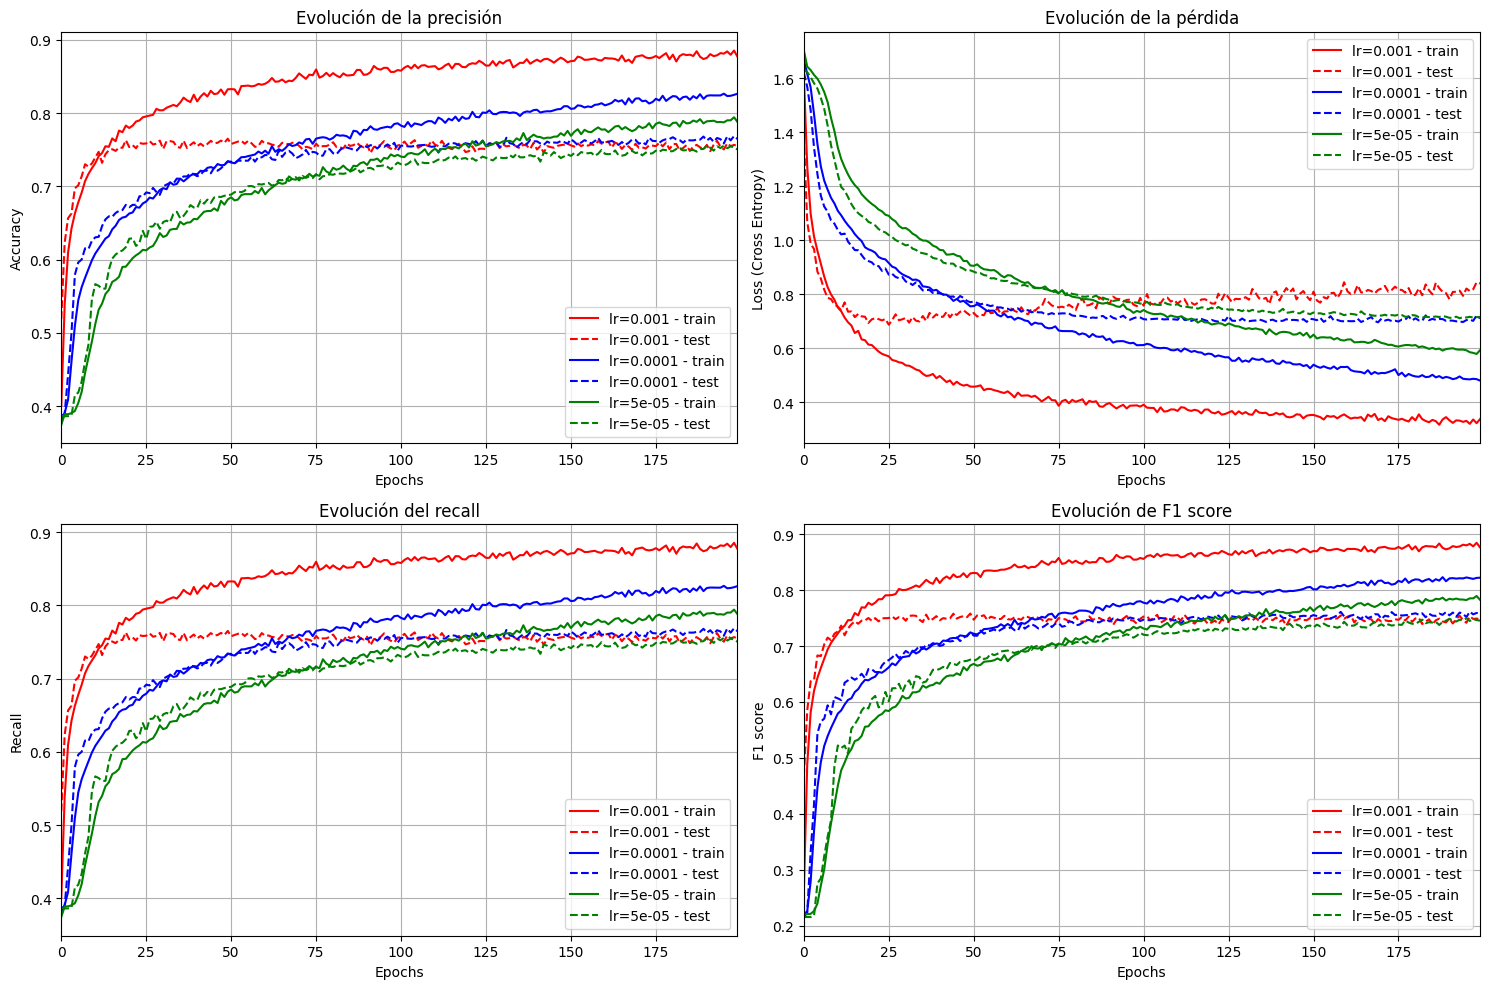

In [64]:
fig, axs = plt.subplots(2,2, figsize=(15,10))
colors = {
    1e-3: 'red',
    1e-4: 'blue',
    5e-5: 'green',
}
for lr in [1e-3, 1e-4, 5e-5]:
    axs[0][0].plot(range(epochs), lr_comp[lr]['ac'], label=f'lr={lr} - train', color=colors[lr])
    axs[0][0].plot(range(epochs), lr_comp[lr]['ac_test'], label=f'lr={lr} - test', color=colors[lr], linestyle='dashed')
# axs[0][0].plot([0, epochs-1], [ac_evol_test[-1], ac_evol_test[-1]] , label='test')
axs[0][0].set_title('Evolución de la precisión')
axs[0][0].set_ylabel('Accuracy')
axs[0][0].set_xlabel('Epochs')
axs[0][0].set_xlim(0, epochs-1)
axs[0][0].grid()
axs[0][0].legend()

for lr in [1e-3, 1e-4, 5e-5]:
    axs[0][1].plot(range(epochs), lr_comp[lr]['loss_evol'], label=f'lr={lr} - train', color=colors[lr])
    axs[0][1].plot(range(epochs), lr_comp[lr]['loss_evol_test'], label=f'lr={lr} - test', color=colors[lr], linestyle='dashed')
axs[0][1].set_title('Evolución de la pérdida')
axs[0][1].set_ylabel('Loss (Cross Entropy)')
axs[0][1].set_xlabel('Epochs')
axs[0][1].set_xlim(0, epochs-1)
axs[0][1].grid()
axs[0][1].legend()

for lr in [1e-3, 1e-4, 5e-5]:
    axs[1][0].plot(range(epochs), lr_comp[lr]['recall'], label=f'lr={lr} - train', color=colors[lr])
    axs[1][0].plot(range(epochs), lr_comp[lr]['recall_test'], label=f'lr={lr} - test', color=colors[lr], linestyle='dashed')
axs[1][0].set_title('Evolución del recall')
axs[1][0].set_ylabel('Recall')
axs[1][0].set_xlabel('Epochs')
axs[1][0].set_xlim(0, epochs-1)
axs[1][0].grid()
axs[1][0].legend()

for lr in [1e-3, 1e-4, 5e-5]:
    axs[1][1].plot(range(epochs), lr_comp[lr]['f1'], label=f'lr={lr} - train', color=colors[lr])
    axs[1][1].plot(range(epochs), lr_comp[lr]['f1_test'], label=f'lr={lr} - test', color=colors[lr], linestyle='dashed')
axs[1][1].set_title('Evolución de F1 score')
axs[1][1].set_ylabel('F1 score')
axs[1][1].set_xlabel('Epochs')
axs[1][1].set_xlim(0, epochs-1)
axs[1][1].grid()
axs[1][1].legend()

plt.tight_layout()
plt.show()

Se observa que con learning rate 1e-4 se tiene un buen balance entre métricas de entrenamiento y de evaluación. La cantidad de epochs también es importante, ya que se puede observar como a partir de cierta cantidad de epochs se empieza a separar la curva de entrenamiento de la de evaluación, indicando que se comienza a tener sobreajuste. Por este motivo se decide utilizar 75 epochs para el entrenamiento del modelo.

Entrenamos el modelo teniendo esto en cuenta:

In [74]:
epochs = 75
lr = 1e-4

model = CNN(device=device, img_size=100, in_channels=3, layers=3, ch_per_layer=8, kernel_size=4, pool_kernel_size=2)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss = torch.nn.CrossEntropyLoss()

loss_evol, ac_evol, recall_evol, f1_evol, loss_evol_test, ac_evol_test, recall_evol_test, f1_evol_test = train_model(model, dataloader['train'], dataloader['test'], epochs, optimizer, loss)

----------------------------------------------
Red creada:
Sequential(
  (conv_0): Conv2d(3, 8, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_0): LeakyReLU(negative_slope=0.01)
  (pool_0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_0): Dropout2d(p=0.1, inplace=False)
  (conv_1): Conv2d(8, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_1): LeakyReLU(negative_slope=0.01)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_1): Dropout2d(p=0.1, inplace=False)
  (conv_2): Conv2d(16, 32, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (act_2): LeakyReLU(negative_slope=0.01)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten()
  (drop): Dropout(p=0.5, inplace=False)
  (fully_connected): Linear(in_features=5408, out_features=7, bias=True)
)
----------------------------------------------
Epoch 0:
 Train Loss = 1.6713
 Train A

## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`, separando claramente los datos de entrenamiento y validación en las gráficas.


A continuación se tienen los gráficos de métricas en función de las epochs entrenadas:

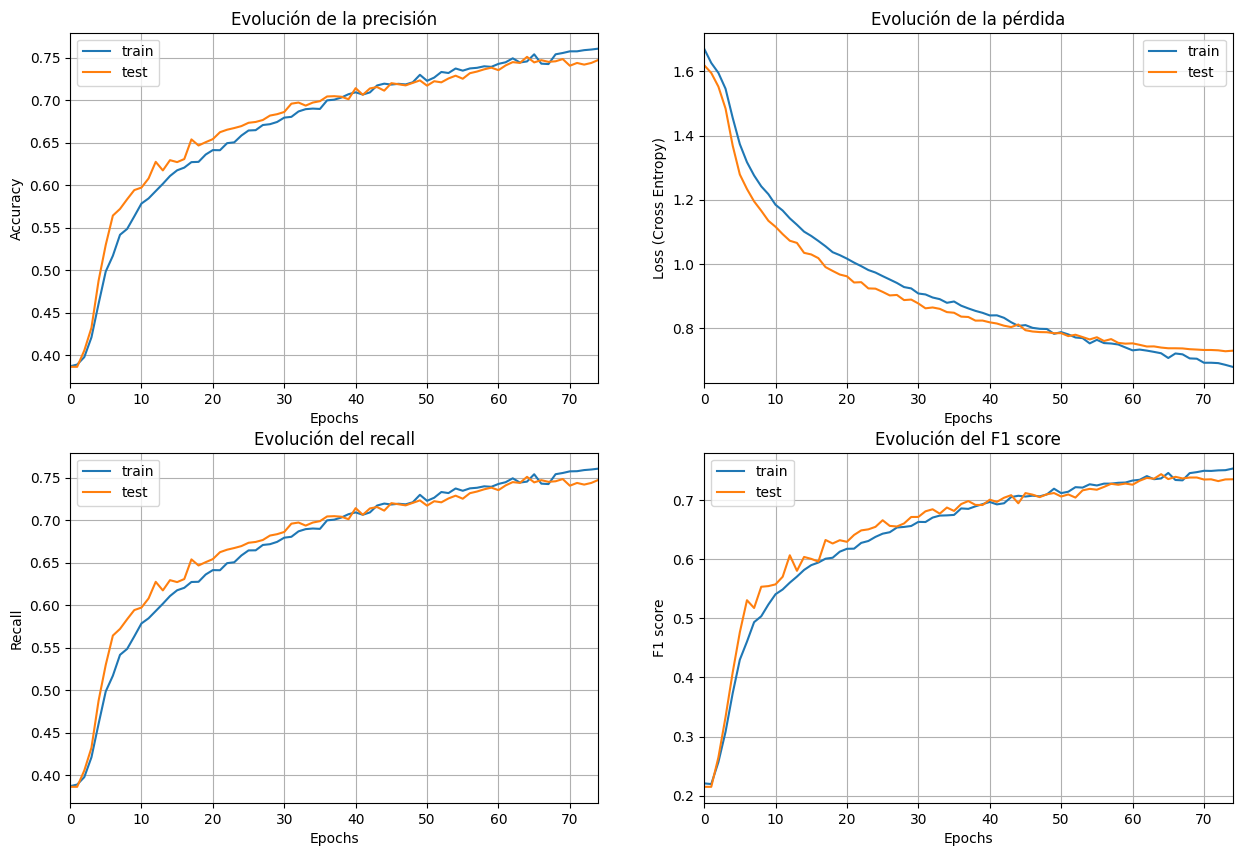

In [75]:
fig, axs = plt.subplots(2,2, figsize=(15,10))

axs[0][0].plot(range(epochs), ac_evol, label='train')
axs[0][0].plot(range(epochs), ac_evol_test, label='test')
axs[0][0].set_title('Evolución de la precisión')
axs[0][0].set_ylabel('Accuracy')
axs[0][0].set_xlabel('Epochs')
axs[0][0].set_xlim(0, epochs-1)
axs[0][0].grid()
axs[0][0].legend()

axs[0][1].plot(range(epochs), loss_evol, label='train')
axs[0][1].plot(range(epochs), loss_evol_test, label='test')
axs[0][1].set_title('Evolución de la pérdida')
axs[0][1].set_ylabel('Loss (Cross Entropy)')
axs[0][1].set_xlabel('Epochs')
axs[0][1].set_xlim(0, epochs-1)
axs[0][1].grid()
axs[0][1].legend()

axs[1][0].plot(range(epochs), recall_evol, label='train')
axs[1][0].plot(range(epochs), recall_evol_test, label='test')
axs[1][0].set_title('Evolución del recall')
axs[1][0].set_ylabel('Recall')
axs[1][0].set_xlabel('Epochs')
axs[1][0].set_xlim(0, epochs-1)
axs[1][0].grid()
axs[1][0].legend()

axs[1][1].plot(range(epochs), f1_evol, label='train')
axs[1][1].plot(range(epochs), f1_evol_test, label='test')
axs[1][1].set_title('Evolución del F1 score')
axs[1][1].set_ylabel('F1 score')
axs[1][1].set_xlabel('Epochs')
axs[1][1].set_xlim(0, epochs-1)
axs[1][1].grid()
axs[1][1].legend()

Evaluemos el modelo entrenado con los datasets de entrenamiento y de evaluación:

In [76]:
y_train = []
yhat_train = []

model.eval()
with torch.no_grad():
    for x_tr, y_tr in dataloader['train']:
        x_tr = x_tr.to(device)
        yhat_tr = model(x_tr)
        y_train.append(y_tr)
        yhat_train.append(yhat_tr.cpu())

    x_test, y_test = next(iter(dataloader['test']))
    x_test = x_test.to(device) 
    yhat_test = model(x_test)
    yhat_test = yhat_test.cpu()

y_train = torch.cat(y_train, dim=0)
yhat_train = torch.cat(yhat_train, dim=0)
yhat_train = yhat_train.argmax(dim=1)

yhat_test = yhat_test.argmax(dim=1)


Las principales métricas finales para entrenamiento y test son:

In [77]:
metrics = {
    'Train': {
        'Accuracy' : accuracy_score(y_train, yhat_train),
        'Recall' : recall_score(y_train, yhat_train, average='weighted'),
        'F1 score' : f1_score(y_train, yhat_train, average='weighted'),
    },
    'Test': {
        'Accuracy' : accuracy_score(y_test, yhat_test),
        'Recall' : recall_score(y_test, yhat_test, average='weighted'),
        'F1 score' : f1_score(y_test, yhat_test, average='weighted'),
    },
}
metrics = pd.DataFrame(metrics)
metrics

,Train,Test
Accuracy,0.809469,0.747392
Recall,0.809469,0.747392
F1 score,0.801704,0.734989


Tenemos el siguiente clasification report:

In [79]:
cr_train = classification_report(y_train, yhat_train)
print('Classification report para dataset de train')
print(cr_train)
cr_test = classification_report(y_test, yhat_test)
print('\nClassification report para dataset de test')
print(cr_test)


Classification report para dataset de train
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4772
           1       0.86      0.36      0.50       717
           2       0.76      0.76      0.76       705
           3       0.94      0.52      0.67       281
           4       0.70      0.86      0.78      2524
           5       0.86      0.80      0.83      1290
           6       0.78      0.66      0.71      1982

    accuracy                           0.81     12271
   macro avg       0.82      0.70      0.74     12271
weighted avg       0.81      0.81      0.80     12271


Classification report para dataset de test
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1185
           1       0.61      0.22      0.32       160
           2       0.65      0.67      0.66       162
           3       0.79      0.36      0.50        74
           4       0.67      0.79      0.72 

Y a continuación tenemos las matrices de confusión (nominales y normalizadas):

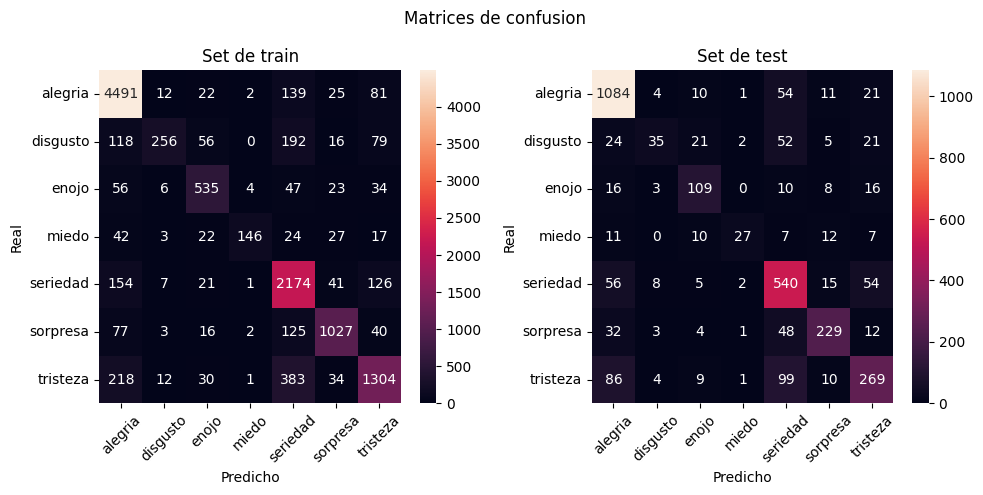

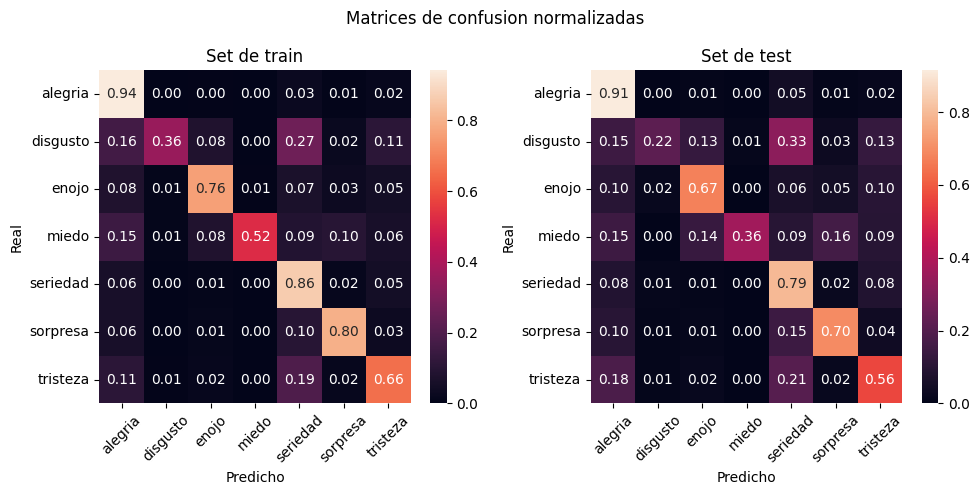

In [80]:
cm_train = confusion_matrix(y_train, yhat_train)
cm_test = confusion_matrix(y_test, yhat_test)

fig, axs = plt.subplots(1,2,figsize=(10,5))
sns.heatmap(data=cm_train, ax=axs[0], annot=True, fmt='d')
sns.heatmap(data=cm_test, ax=axs[1], annot=True, fmt='d')
axs[0].set_title('Set de train')
axs[1].set_title('Set de test')
[axs[i].set_xlabel('Predicho') for i in range(2)]
[axs[i].set_ylabel('Real') for i in range(2)]
[axs[i].set_xticks(np.arange(7) + 0.5,['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza'], rotation=45) for i in range(2)]
[axs[i].set_yticks(np.arange(7) + 0.5,['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza'], rotation=0) for i in range(2)]
fig.suptitle('Matrices de confusion')
plt.tight_layout()
plt.show()

cm_train_norm = confusion_matrix(y_train, yhat_train, normalize='true')
cm_test_norm = confusion_matrix(y_test, yhat_test, normalize='true')

fig, axs = plt.subplots(1,2,figsize=(10,5))
sns.heatmap(data=cm_train_norm, ax=axs[0], annot=True, fmt='.2f')
sns.heatmap(data=cm_test_norm, ax=axs[1], annot=True, fmt='.2f')
axs[0].set_title('Set de train')
axs[1].set_title('Set de test')
[axs[i].set_xlabel('Predicho') for i in range(2)]
[axs[i].set_ylabel('Real') for i in range(2)]
[axs[i].set_xticks(np.arange(7) + 0.5,['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza'], rotation=45) for i in range(2)]
[axs[i].set_yticks(np.arange(7) + 0.5,['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza'], rotation=0) for i in range(2)]
fig.suptitle('Matrices de confusion normalizadas')
plt.tight_layout()
plt.show()


 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 10 imágenes personales de cualquier relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

Importmaos las imagenes nuevas, teniendo un dataloader para las imagenes sin procesamiento y otro con procesamiento.

In [17]:
new_data_org = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(root='my_dataset/', transform=transforms.ToTensor()), batch_size=1)
print(new_data_org)
new_data = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(root='my_dataset/', transform=composition), batch_size=1)
print(new_data)

Evaluamos el modelo con estas nuevas imagenes:

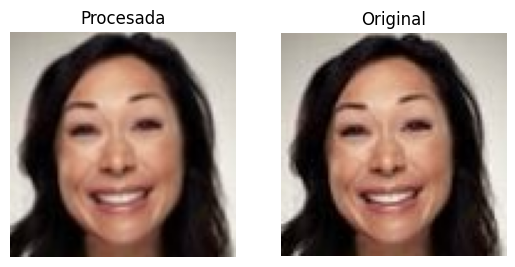

 alegria  disgusto  enojo    miedo  seriedad  sorpresa  tristeza
0.729212       0.0    1.0 0.269731   0.67842   0.90654  0.574859
Emocion predicha: enojo
Emocion real: alegria


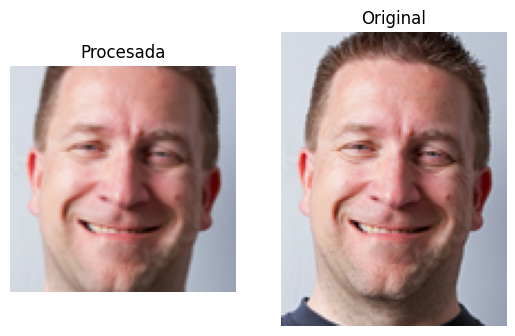

 alegria  disgusto  enojo    miedo  seriedad  sorpresa  tristeza
0.455474  0.493197    1.0 0.144589  0.216292       0.0  0.548588
Emocion predicha: enojo
Emocion real: alegria


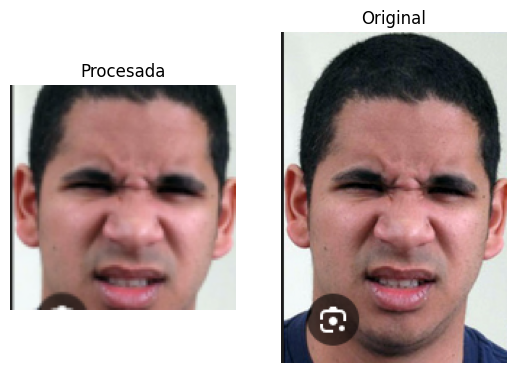

 alegria  disgusto    enojo  miedo  seriedad  sorpresa  tristeza
     1.0  0.058865 0.227787    0.0  0.873745  0.933082  0.432778
Emocion predicha: alegria
Emocion real: disgusto


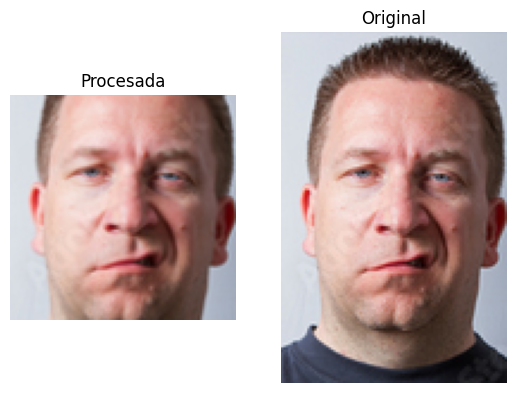

 alegria  disgusto    enojo  miedo  seriedad  sorpresa  tristeza
0.417238       1.0 0.619838    0.0  0.587338  0.343724  0.648983
Emocion predicha: disgusto
Emocion real: disgusto


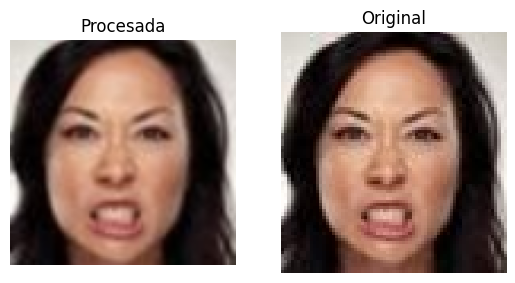

 alegria  disgusto  enojo  miedo  seriedad  sorpresa  tristeza
0.762946  0.563525    1.0    0.0  0.711615  0.825712  0.124944
Emocion predicha: enojo
Emocion real: enojo


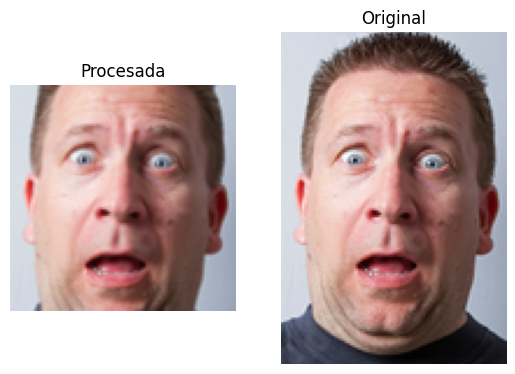

 alegria  disgusto  enojo    miedo  seriedad  sorpresa  tristeza
0.383748  0.123278    0.0 0.146887  0.346086       1.0  0.946698
Emocion predicha: sorpresa
Emocion real: miedo


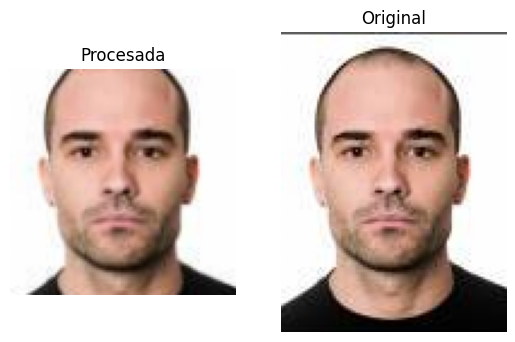

 alegria  disgusto  enojo    miedo  seriedad  sorpresa  tristeza
0.570973  0.507148    1.0 0.788462       0.0   0.32082  0.548593
Emocion predicha: enojo
Emocion real: seriedad


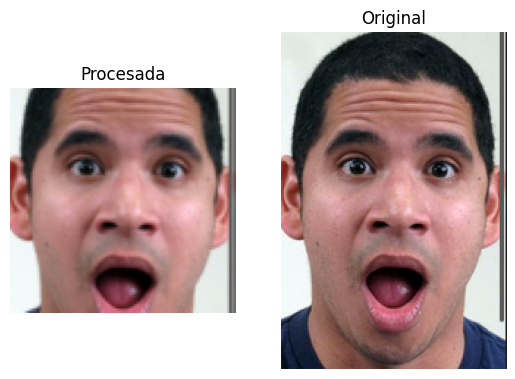

 alegria  disgusto    enojo  miedo  seriedad  sorpresa  tristeza
     1.0  0.542242 0.020141    0.0  0.890513  0.451894  0.661281
Emocion predicha: alegria
Emocion real: sorpresa


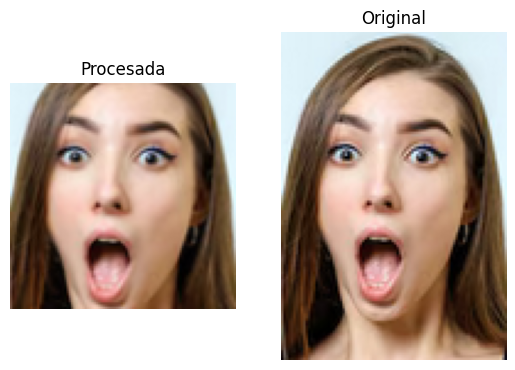

 alegria  disgusto  enojo    miedo  seriedad  sorpresa  tristeza
0.320012  0.522545    0.0 0.282823  0.841168       1.0  0.792975
Emocion predicha: sorpresa
Emocion real: sorpresa


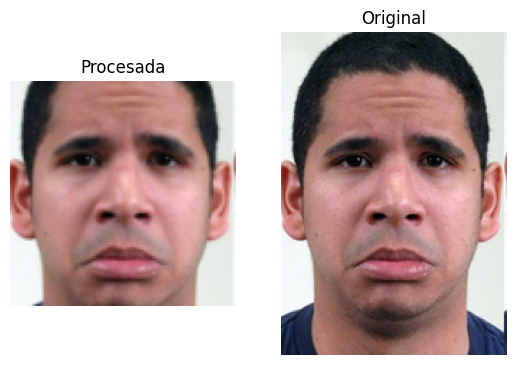

 alegria  disgusto    enojo  miedo  seriedad  sorpresa  tristeza
0.523047  0.898737 0.365735    0.0  0.599653   0.54647       1.0
Emocion predicha: tristeza
Emocion real: tristeza
Resumen:
       Real  Predicho
0   alegria     enojo
1   alegria     enojo
2  disgusto   alegria
3  disgusto  disgusto
4     enojo     enojo
5     miedo  sorpresa
6  seriedad     enojo
7  sorpresa   alegria
8  sorpresa  sorpresa
9  tristeza  tristeza


In [ ]:
emociones = ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
summary = []
for i, (batch_1, batch_2) in enumerate(zip(new_data, new_data_org)):
    x, y = batch_1
    x_org, _ = batch_2

    # visualizacion de las imagenes
    img_np = torch.clamp(x, 0, 1).permute(0,2,3,1).numpy()[0]
    img_np_org = torch.clamp(x_org, 0, 1).permute(0,2,3,1).numpy()[0]
    fig, axs = plt.subplots(1,2)
    axs[0].imshow(img_np)
    axs[0].set_title('Procesada')
    axs[1].imshow(img_np_org)
    axs[1].set_title('Original')
    [axs[i].set_axis_off() for i in range(2)]
    plt.show()

    # prediccion de la clase con el modelo
    x = x.to(device)
    model.eval()
    with torch.no_grad():
        yhat = model(x)
    # normalize y hat
    yhat = yhat.cpu().numpy().flatten()
    yhat_min, yhat_max = yhat.min(), yhat.max()
    for i in range(len(yhat)):
        val = yhat[i]
        yhat[i] = (val - yhat_min)/(yhat_max - yhat_min)
    yhat_df = pd.DataFrame([yhat], columns=emociones)
    print(yhat_df.to_string(index=False))
    # valor predicho
    predicted = yhat.argmax()
    print(f'Emocion predicha: {emociones[predicted]}')
    print(f'Emocion real: {emociones[y]}')

    summary.append([emociones[y], emociones[predicted]])


A continuación tenemos el resumen de lo real y lo predicho.

In [ ]:
print('Resumen:')
print(pd.DataFrame(summary, columns=['Real', 'Predicho']))

Podemos observar que el modelo tiende a confundir alegría con enojo, lo cual es raro porque en las matrices de confusión se veía que la alegría era la emoción que mejor tasa de verdaderos positivos entregaba.

También el modelo confundía seriedad con enojo, miedo con sorpesa y seriedad con enojo. Esto no resulta extraño, ya que podrían confundirse las expresiones en estos casos.

En esta pequeña prueba los verdaderos positivos del modelo fueron 4/10, lo cual está bastante por debajo de los valores de precisión que se vieron anteriormente.

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 10 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

NOTA: Pueden adaptar el código y modificar el `scaleFactor` y el `minNeighbors` según crean conveniente para obtener mejores resultados.

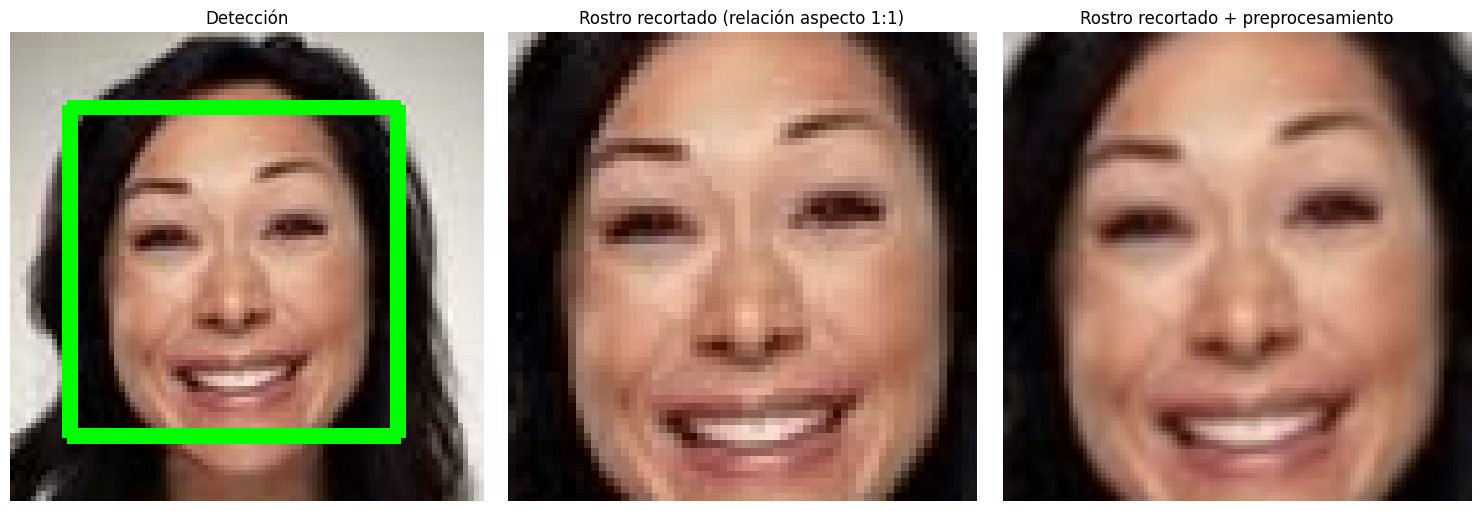

tensor([[ 1.9920, -5.1892, -4.1141, -3.4841, -3.6587, -1.5535, -3.3366]])
alegria


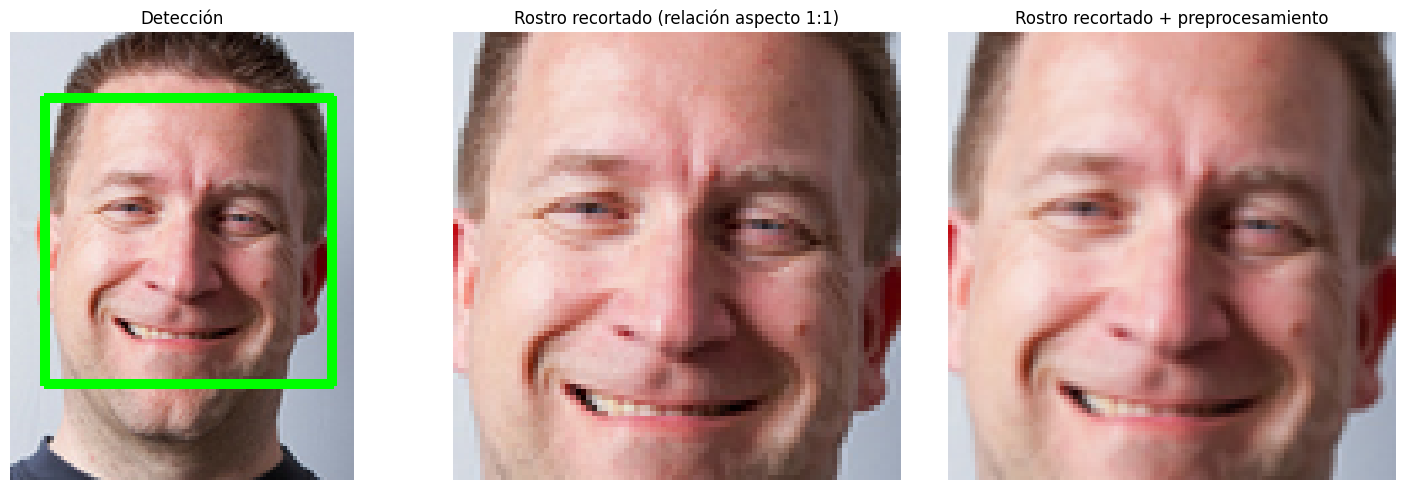

tensor([[ 0.4922, -2.7822, -2.4678, -3.6557, -2.2478, -4.6412, -0.9072]])
alegria


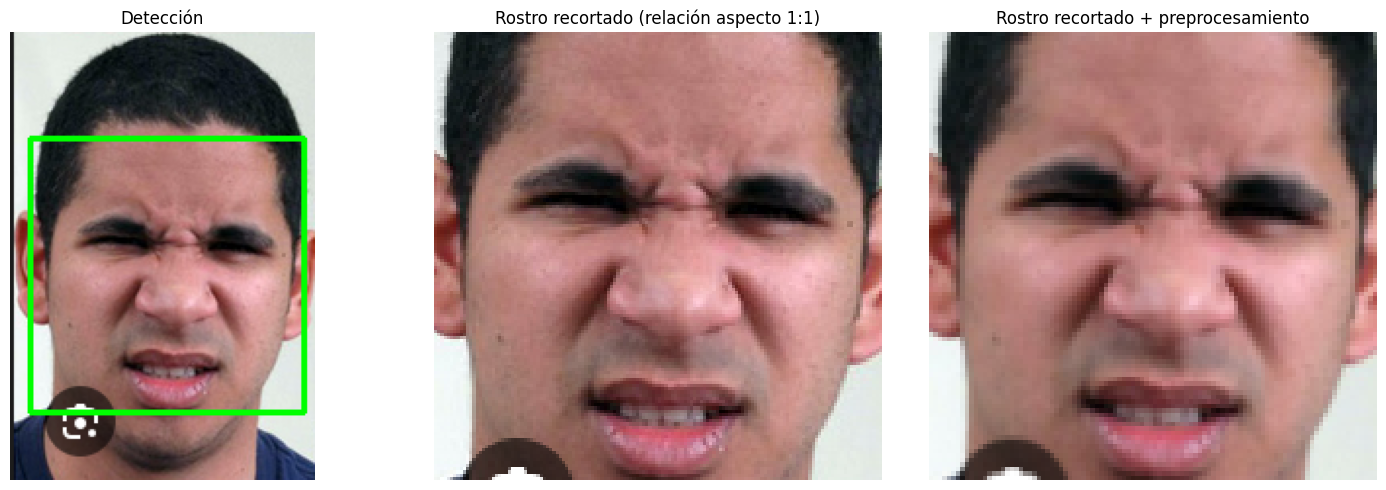

tensor([[-0.3419, -1.3837, -2.7651, -4.7900, -3.6672, -3.3384, -1.1853]])
alegria


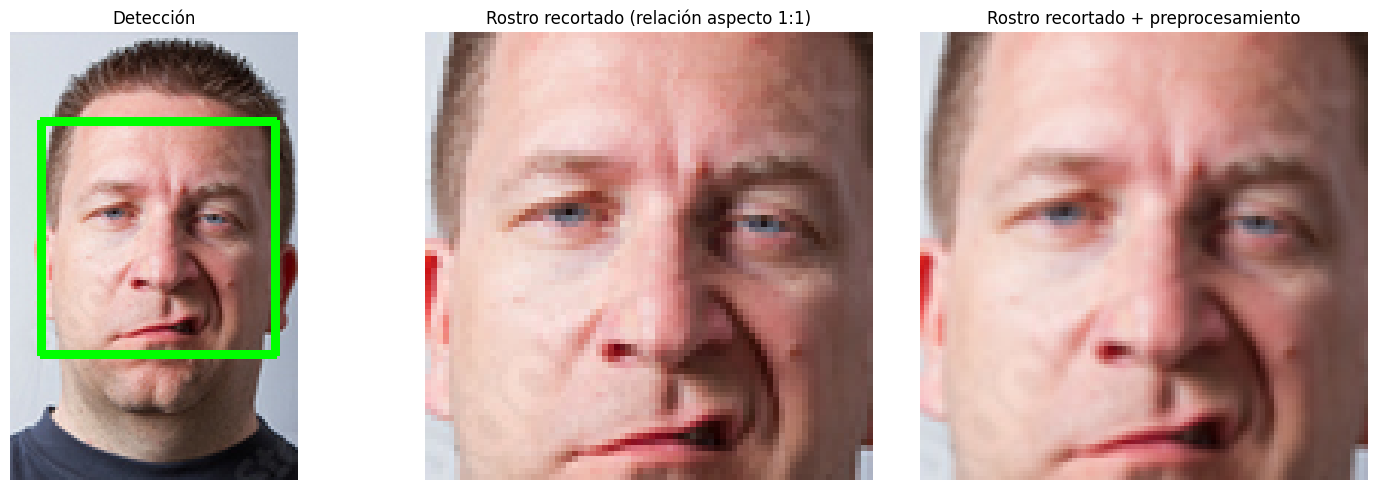

tensor([[-0.2491, -2.4621, -1.3447, -4.6698, -2.0420, -3.0603, -0.7992]])
alegria


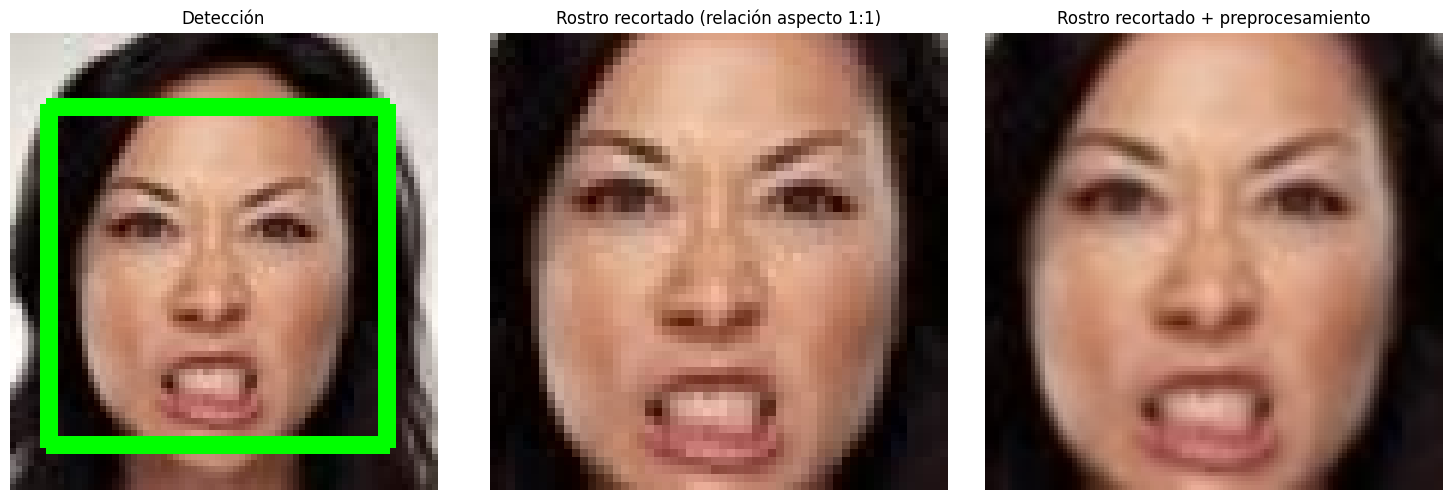

tensor([[ 1.1037, -2.2242, -2.4263, -5.7566, -2.5341, -2.7542, -1.3063]])
alegria


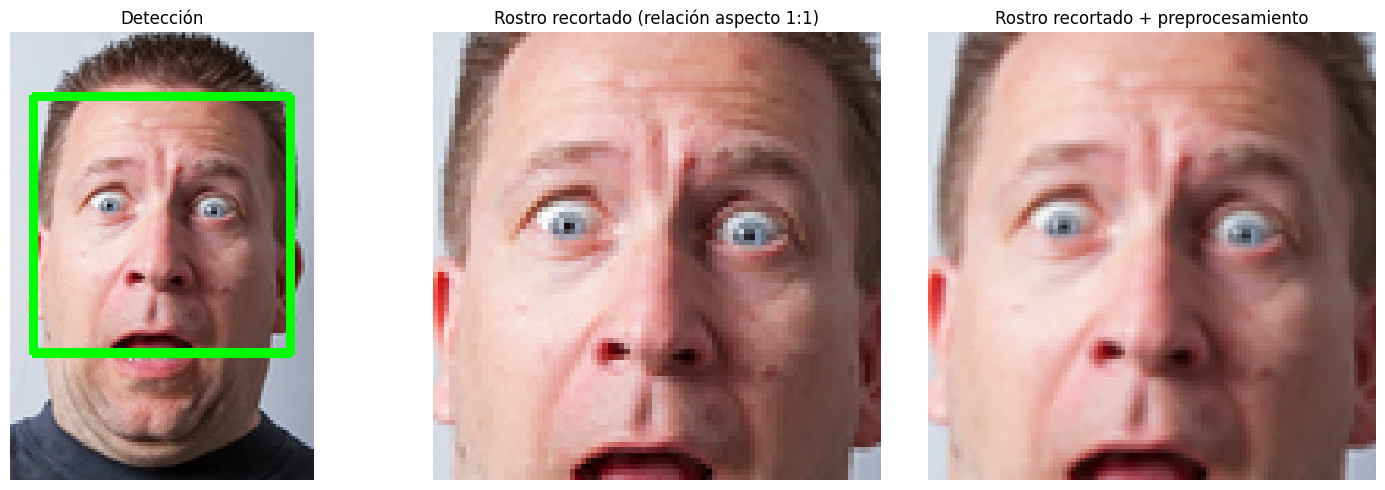

tensor([[-2.8708, -2.7728, -2.4360, -4.2148,  0.6113, -1.4785,  0.4957]])
seriedad


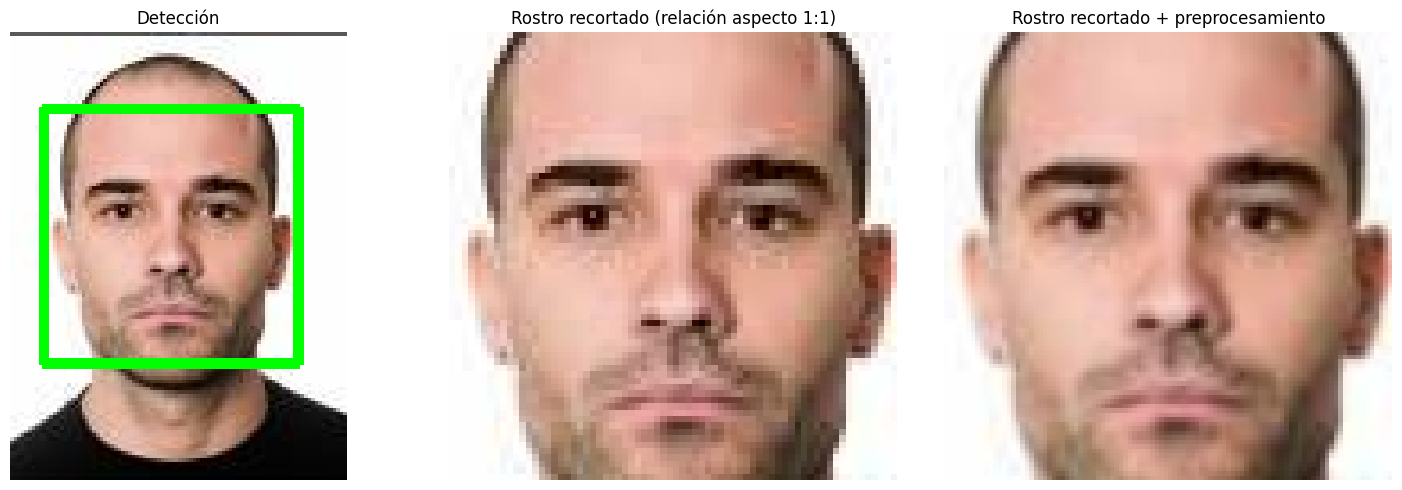

tensor([[-1.3869, -1.0745, -1.4417, -7.7190, -1.9834, -3.2393, -1.3861]])
disgusto


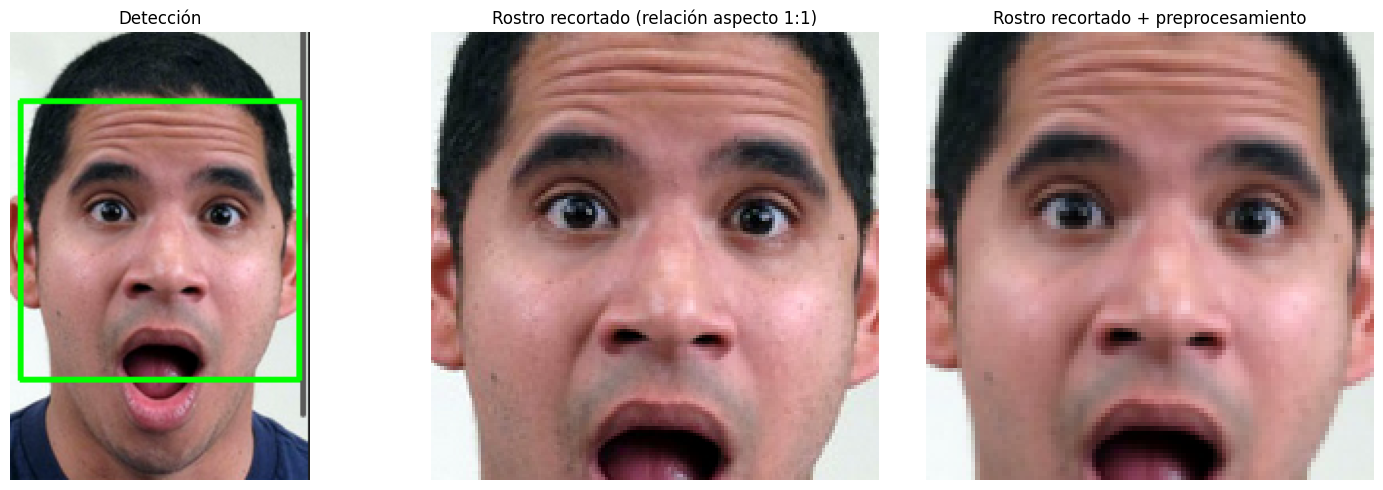

tensor([[-0.1841, -2.2554, -6.5488, -4.7503, -0.2788, -1.0058, -1.4551]])
alegria


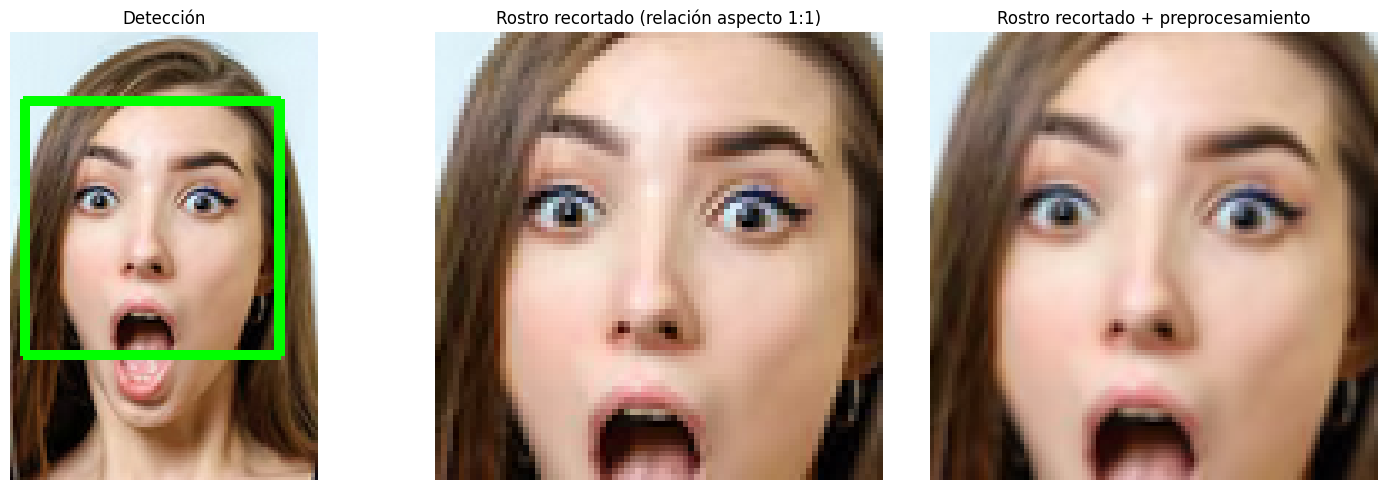

tensor([[ 1.9807, -3.7879, -5.9890, -5.9611, -0.8217, -1.7867, -3.7990]])
alegria


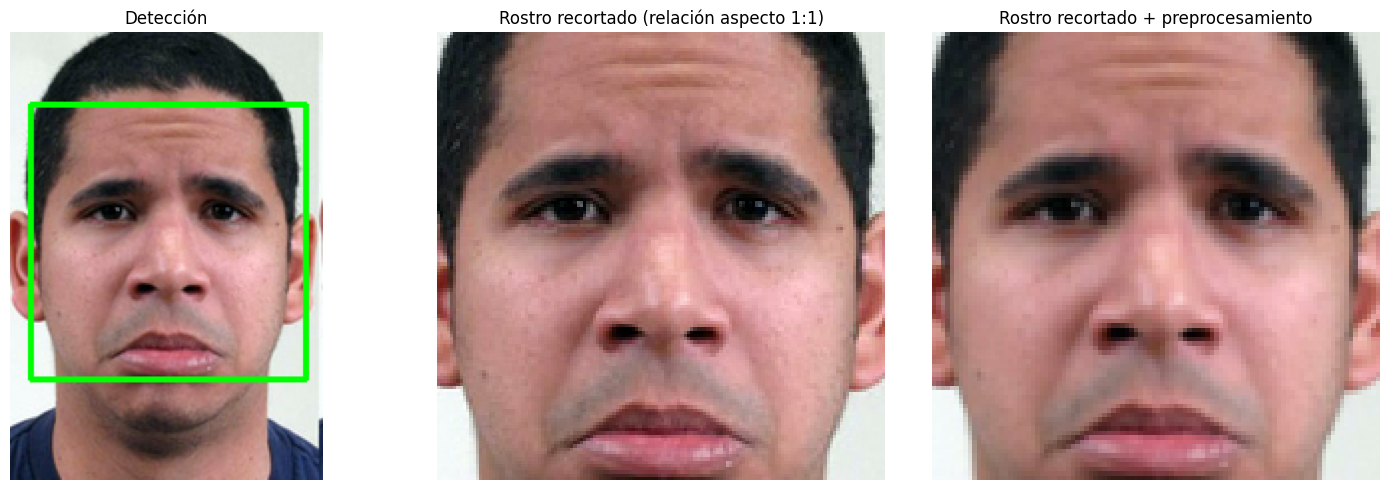

tensor([[-0.9121, -1.3428, -3.8358, -5.5117, -2.8495, -2.7736, -0.3690]])
tristeza


In [60]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

for i, image_path in enumerate([
     "my_dataset/alegria/alegria.png",
     "my_dataset/alegria/alegria2.png",
     "my_dataset/disgusto/disgusto.png",
     "my_dataset/disgusto/disgusto2.png",
     "my_dataset/enojo/enojo.png",
     "my_dataset/miedo/miedo.png",
     "my_dataset/seriedad/seriedad.png",
     "my_dataset/sorpresa/sorpresa.png",
     "my_dataset/sorpresa/sorpresa2.png",
     "my_dataset/tristeza/tristeza.png",
]):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6)

    image_with_box = image.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

    cropped_face_rgb = None
    if len(faces) > 0:
        (x, y, w, h) = faces[0]
        center_x, center_y = x + w // 2, y + h // 2
        side = max(w, h)
        half_side = side // 2

        x1 = max(center_x - half_side, 0)
        y1 = max(center_y - half_side, 0)
        x2 = min(center_x + half_side, image.shape[1])
        y2 = min(center_y + half_side, image.shape[0])

        cropped_face = image[y1:y2, x1:x2]
        cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

    image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(image_with_box_rgb)
    ax[0].set_title("Detección")
    ax[0].axis('off')

    if cropped_face_rgb is not None:
        ax[1].imshow(cropped_face_rgb)
        ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
        ax[1].axis('off')
    else:
        ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
        ax[1].axis('off')

    X_cropped = composition(Image.fromarray(cropped_face_rgb))
    ax[2].imshow(torch.clamp(X_cropped, 0, 1).permute(1,2,0).numpy())
    ax[2].set_title('Rostro recortado + preprocesamiento')
    ax[2].axis('off')
    plt.tight_layout()
    plt.show()

    X_cropped = X_cropped.reshape(1,3,100,100).to(device)

    model.eval()
    with torch.no_grad():
        yhat = model(X_cropped).cpu()
        predicted = emociones[yhat.argmax()]
        print(yhat)
        print(predicted)
        summary[i].append(predicted)


A continuación podemos ver agregado al resumen anterior la columna con el preproceso propuesto.

Se observa que ahora si se tiene una sobrepredicción de alegría, más en línea con lo que se observaba en la matriz de confusión. Esto puede indicarnos que las imágenes originalmente utilizadas para entrenamiento y testeo vienen de algún modelo de preprocesamiento similar al utilizado aquí.

En este caso se tiene un acierto de 3/10, pero que en el caso anterior.

In [55]:
print('Resumen:')
print(pd.DataFrame(summary, columns=['Real', 'Predicho', 'Predicho con preproceso']))

Resumen:
       Real  Predicho Predicho con preproceso
0   alegria     enojo                 alegria
1   alegria     enojo                 alegria
2  disgusto   alegria                 alegria
3  disgusto  disgusto                 alegria
4     enojo     enojo                 alegria
5     miedo  sorpresa                seriedad
6  seriedad     enojo                disgusto
7  sorpresa   alegria                 alegria
8  sorpresa  sorpresa                 alegria
9  tristeza  tristeza                tristeza


**Conclusiones**

Se desarrolló una red convolucional para detección de emociones en función de las expresiones faciales. Se obtuvieron resultados aceptables de precisión en entrenamiento y con el set de testeo provisto, pero al utilizar nuevas imágenes se obtuvieron resultados bastante pobres. 

Aún así, no se debería descartar el modelo, si no que el mayor punto de mejora está en el set de imagenes a utilizar en entrenamiento y el preprocesamiento que tienen. En particular, si se aplicó un reconocimiento de dónde está la cara de la persona en la imagen para luego recortar, ya que es clave que se tenga toda la cara disponible para capturar posibles tendencias.